## Week 1: Build Basic MD Engine

### Code that solves Newton's equations for molecules.

##### Input: Initial positons and velocities of atoms AND potential energy (atom-atom interactions)
##### Output: Series of snapshot positions and velocities (MD trajectory/movie)

In [ ]:
#libraries

import numpy as np
import matplotlib.pyplot as plt
#import random

#On paper: Underscore = Vector. Dot above = Integral

#### Task 1.1: Implement Euler integrator for 1D Harmonic Oscillator

Key Equations:

Newton's 2nd Equation: F = ma

Calculating force via PE: F = -∇U

Euler Integrator: 



U(r): Potential energy as a function of position

∇U: Vector that measures direction of U and magnitude of slope

In [ ]:
seed_value = 1 ; seed = np.random.default_rng(seed=seed_value) #sets random seed using numpy (instead of 'random' library)

#input
initial_pos = seed.random() #initial position [0.5118216247002567]
initial_vel = seed.random() #initial velocity [0.9504636963259353]
potential_e = seed.random() #potential energy (atom-atom interactions) [0.14415961271963373]

#N = 5 #number of particles?
#next_vel = np.zeros(N) #next velocity at the next time step (np.empty also should work)

snapshots = 50

dt_step = 0.001 #Approximation of derivative dt
time = np.arange(snapshots) * dt_step

energy = np.zeros(snapshots)

k = 1 #Spring constant value
m = 0.5 #Mass


#initial_pos = 5


In [ ]:
time.size

50

In [ ]:
# This is going to register the time and energy at each snapshot

x_step = np.zeros(snapshots) ; v_step = np.zeros(snapshots) ; force = np.zeros(snapshots)

x = initial_pos ; v = initial_vel


for i in range(snapshots):

    x_next = x + (v * dt_step)
    x_step[i] = x_next

    force[i] = -k * x

    v_next = v + ((1/m) * force[i]* dt_step) 
    v_step[i] = v_next

    #time[i] = i

    energy[i] = (0.5 * k * np.power(x, 2)) + (0.5 * m * np.power(v, 2))

        
    
    x = x_next ; v = v_next



# old code
'''
for count in range(snapshots):
    if count == 0:
        x = initial_pos ; v = initial_vel

        x_next = x + (v * time[count])
        x_step[count] = x_next

        v_next = v + ((1/m) * (2*time[count]))    # replace 50 with force
        v_step[count] = v_next

        time[count] = count

    else:
        x = x_next ; v = v_next

        x_next = x + (v * time[count])
        x_step[count] = x_next

        v_next = v + (1/m)*1 + (50*time[count])    # replace 50 with force
        v_step[count] = v_next

        time[count] = count

        #continue code here!
        
        

    pass
'''


'\nfor count in range(snapshots):\n    if count == 0:\n        x = initial_pos ; v = initial_vel\n\n        x_next = x + (v * time[count])\n        x_step[count] = x_next\n\n        v_next = v + ((1/m) * (2*time[count]))    # replace 50 with force\n        v_step[count] = v_next\n\n        time[count] = count\n\n    else:\n        x = x_next ; v = v_next\n\n        x_next = x + (v * time[count])\n        x_step[count] = x_next\n\n        v_next = v + (1/m)*1 + (50*time[count])    # replace 50 with force\n        v_step[count] = v_next\n\n        time[count] = count\n\n        #continue code here!\n        \n        \n\n    pass\n'

In [ ]:
energy

array([0.356826  , 0.35682671, 0.35682742, 0.35682814, 0.35682885,
       0.35682957, 0.35683028, 0.35683099, 0.35683171, 0.35683242,
       0.35683313, 0.35683385, 0.35683456, 0.35683527, 0.35683599,
       0.3568367 , 0.35683742, 0.35683813, 0.35683884, 0.35683956,
       0.35684027, 0.35684098, 0.3568417 , 0.35684241, 0.35684313,
       0.35684384, 0.35684455, 0.35684527, 0.35684598, 0.35684669,
       0.35684741, 0.35684812, 0.35684883, 0.35684955, 0.35685026,
       0.35685098, 0.35685169, 0.3568524 , 0.35685312, 0.35685383,
       0.35685454, 0.35685526, 0.35685597, 0.35685669, 0.3568574 ,
       0.35685811, 0.35685883, 0.35685954, 0.35686025, 0.35686097])

#### Task 1.2: Calculate/plot E(t) and check what values of Δt does to E(t) 

Key Equations:

PE: U(x) = (1/2) kx<sup>2</sup>

KE: K(v) = (1/2) mv<sup>2</sup>

Hooke's Law: F(x) = -kx

** E(x,v) = (1/2) kx<sup>2</sup> + (1/2) mv<sup>2</sup> (should be constant)




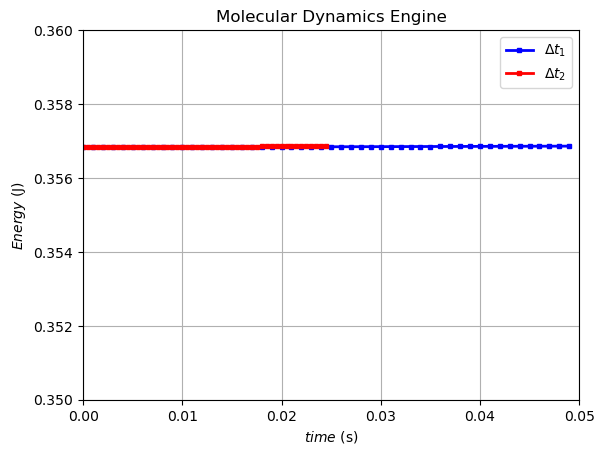

In [ ]:
#Hint: Manually set y limits


plt.plot(figsize=(6,4))
#plt.plot(linear_plot, y1, "bs-", linewidth=2, markersize=4)
plt.xlabel('$time$ (s)') ; plt.ylabel('$Energy$ (J)') #Check if in Joules!!!!

#plt.axis([0, 10.5, 0, 105]) #Sets all axis lengths [xmin, xmax, ymin, ymax]
#plt.ylim(-1.5, 1.5) #Sets y axis lengths

plt.xlim(0, 0.05) ; #plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])
plt.ylim(0.35, 0.36) ; #plt.yticks([-1.0, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])


#-----------------

plt.plot(time, energy, "bs-", linewidth=2, markersize=3, label = "$Δt_1$")
plt.plot(time * 0.5, energy, "rs-", linewidth=2, markersize=3, label = "$Δt_2$")

#-----------------

plt.legend(loc="upper right") ; plt.title("Molecular Dynamics Engine") ; plt.grid(True) ; plt.show()
#plt.savefig("myplot1.pdf")


#SHOULD BE CONSTANT

#### Old Function (1/22) 

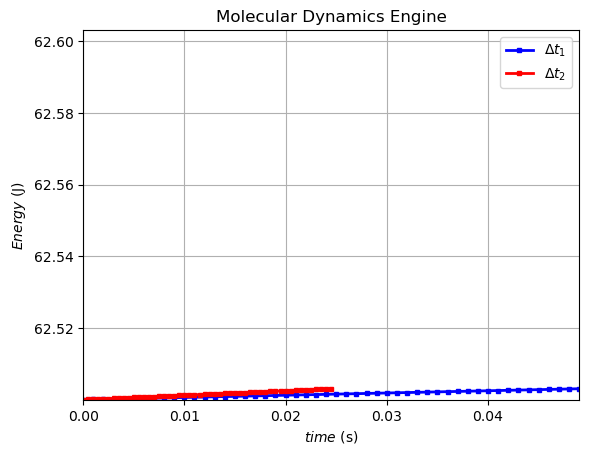

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#I need to use Potential Energy

def BasicMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, k=1, m=1):
    '''Code that solves Newton's equations for molecules using the inputs for initial velocity, initial position, and potential energy'''

    dt_step = 0.001
    time = np.arange(snapshots, dtype=float) * dt_step

    energy = np.zeros(snapshots, dtype=float)

    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)

    x = initial_pos ; v = initial_vel

    
    for i in range(snapshots):

        x_next = x + (v * dt_step)
        x_step[i] = x_next

        force[i] = -k * x

        v_next = v + ((1/m) * force[i]* dt_step) 
        v_step[i] = v_next

        energy[i] = (0.5 * k * np.power(x_next, 2)) + (0.5 * m * np.power(v_next, 2))

            
        
        x = x_next ; v = v_next

    # ------------------------------

    plt.plot(figsize=(6,6))

    plt.xlabel('$time$ (s)') ; plt.ylabel('$Energy$ (J)') 

    #plt.xlim(time[0], time[-1]) ; plt.ylim(energy[0], energy[-1]+ 0.1) # fix 0.1
    plt.xlim(time.min(), time.max()) ; plt.ylim(energy.min(), energy.max() + 0.1)

    plt.plot(time, energy, "bs-", linewidth=2, markersize=3, label = "$Δt_1$")
    plt.plot(time * 0.5, energy, "rs-", linewidth=2, markersize=3, label = "$Δt_2$")

    plt.legend(loc="upper right") ; plt.title("Molecular Dynamics Engine") ; plt.grid(True) ;  plt.show()
    #plt.savefig("myplot1.pdf")


BasicMDEngine(5, 10, 0.14)



#### Old Function (1/23)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



def potential_e(r):
    return r #confused here

def BasicMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, k=1, m=1, dt_step = 0.001): #Made dt_step a parameter
    '''Code that solves Newton's equations for molecules using the inputs for initial velocity, initial position, and potential energy'''

    time = np.arange(snapshots, dtype=float) * dt_step

    energy = np.zeros(snapshots, dtype=float)

    x_step = np.zeros((snapshots, 2), dtype=float) ; v_step = np.zeros((snapshots, 2), dtype=float) ; force = np.zeros((snapshots, 2), dtype=float)

    x = np.asarray(initial_pos, dtype=float) ; v = np.asarray(initial_vel, dtype = float) ; h = 0.000001 #  h = 1e-6
    #Arrays to reduce truncation?
    
    for i in range(snapshots):

        r = abs(x[0] - x[1]) #How much each atom will move with each timestep CHECK????

        dU_dr = ((potential_e(r+h) - potential_e(r-h)) / (h*2.0))
        Fr = -dU_dr           
             

        #-------------------------------------------------------------------------------------- Testing

        #New command (np.sign): returns -1 for negative numbers, 0 for zero, and 1 for positive numbers, element-wise for arrays !!!
        if r != 0.0:
            sign = np.sign(x[0]-x[1])
        else:
            sign = 0.0

        F_i = Fr * sign
        F1 = -F_i  #check

        force[i,:] = np.array([F_i , F1])



        #--------------------------------------------------------------------------------------


        x_next = x + (v * dt_step)
        x_step[i] = x_next

        v_next = v + ((1/m) * force[i]* dt_step) 
        v_step[i] = v_next

        r_next = abs(x_next[0] - x_next[1])

        total_pe = potential_e(r)
        total_ke = 0.5 * m * np.sum(v_next**2) 
        
        energy[i] = total_pe + total_ke #Total Energy
        #energy[i] = (0.5 * k * np.power(x_next, 2)) + (0.5 * m * np.power(v_next, 2))

            
        
        x = x_next ; v = v_next

    # ------------------------------

    plt.plot(figsize=(6,6))

    plt.xlabel('$time$ (s)') ; plt.ylabel('$Energy$ (J)') 

    #plt.xlim(time[0], time[-1]) ; plt.ylim(energy[0], energy[-1]+ 0.1) # fix 0.1
    plt.xlim(time.min(), time.max()) ; plt.ylim(energy.min(), energy.max() + 0.1)

    plt.plot(time, energy, "bs-", linewidth=2, markersize=3, label = "$Δt_1$")
    plt.plot(time * 0.5, energy, "rs-", linewidth=2, markersize=3, label = "$Δt_2$")

    plt.legend(loc="upper right") ; plt.title("Molecular Dynamics Engine") ; plt.grid(True) ;  plt.show()
    #plt.savefig("myplot1.pdf")


BasicMDEngine([0, 5],[0, 5], 1.0)



TypeError: 'float' object is not callable

#### Old Function (1/24) [Based off 1/22]

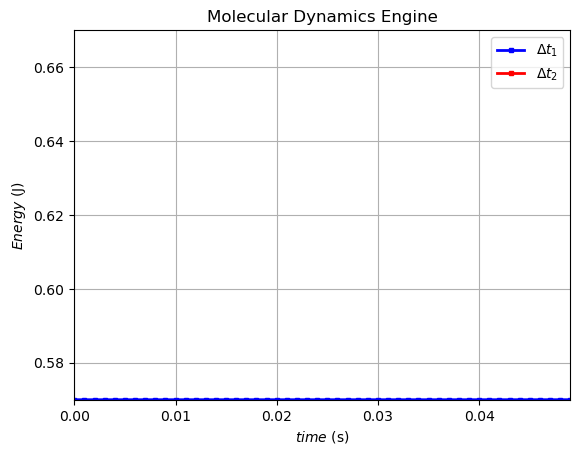

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#I need to use Potential Energy

def BasicMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, m=1):
    '''Code that solves Newton's equations for molecules using the inputs for initial velocity, initial position, and potential energy'''

    dt_step = 0.001
    time = np.arange(snapshots, dtype=float) * dt_step

    energy = np.zeros(snapshots, dtype=float)

    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)

    x = float(initial_pos) ; v = float(initial_vel)

    k = float(potential_e) #We set input PE to the spring constant k for the harmonic oscillator

    
    for i in range(snapshots):

        x_next = x + (v * dt_step)
        x_step[i] = x_next

        F = -k * x
        force[i] = F  #Changed it to be more clear (Hooke's Law)

        v_next = v + ((1/m) * F * dt_step) 
        v_step[i] = v_next

        pe = 0.5 * k * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)

        energy[i] = pe + ke

            
        
        x = x_next ; v = v_next

    # ------------------------------

    plt.plot(figsize=(6,6))

    plt.xlabel('$time$ (s)') ; plt.ylabel('$Energy$ (J)') 

    #plt.xlim(time[0], time[-1]) ; plt.ylim(energy[0], energy[-1]+ 0.1) # fix 0.1
    plt.xlim(time.min(), time.max()) ; plt.ylim(energy.min(), energy.max() + 0.1)

    # ----------------------------------------------------------------------------------New technique i learned :)

    #time_a, x_a, v_a, energy_a = BasicMDEngine(2.0, 5.0, 1.0, snapshots = 2000, dt_step = 0.01)
    #time_b, x_b, v_b, energy_b = BasicMDEngine(2.0, 5.0, 1.0, snapshots = 2000, dt_step = 0.05)

    plt.plot(time, energy, "bs-", linewidth=2, markersize=3, label = "$Δt_1$")
    plt.plot(time, energy *.8, "rs-", linewidth=2, markersize=3, label = "$Δt_2$")

    # ----------------------------------------------------------------------------------

    plt.legend(loc="upper right") ; plt.title("Molecular Dynamics Engine") ; plt.grid(True) ;  plt.show()
    #plt.savefig("myplot1.pdf")

BasicMDEngine(1.0,1.0,0.14)


#### Final Function

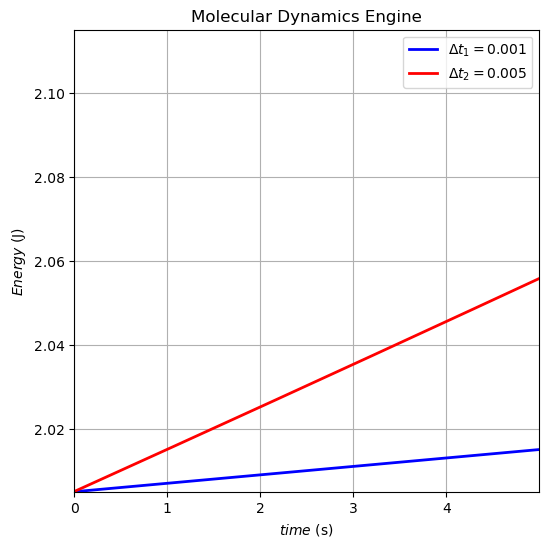

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#I need to use Potential Energy

def BasicMDEngine(initial_pos, initial_vel, potential_e, snapshots=50, m=1, dt_step = 0.001):
    '''Code that solves Newton's equations for molecules using the inputs for initial velocity, initial position, and potential energy'''

    
    time = np.arange(snapshots, dtype=float) * dt_step

    energy = np.zeros(snapshots, dtype=float)

    x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float) ; force = np.zeros(snapshots, dtype=float)

    x = float(initial_pos) ; v = float(initial_vel)

    k = float(potential_e) #We set input PE to the spring constant k for the harmonic oscillator

    
    for i in range(snapshots):

        x_next = x + (v * dt_step)
        x_step[i] = x_next

        F = -k * x
        force[i] = F  #Changed it to be more clear (Hooke's Law)

        v_next = v + ((1/m) * F * dt_step) 
        v_step[i] = v_next

        pe = 0.5 * k * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)

        energy[i] = pe + ke

            
        
        x = x_next ; v = v_next



    return time, x_step, v_step, energy

  

time_a, x_a, v_a, energy_a = BasicMDEngine(2.0, 0.1, 1.0, snapshots = 5000, dt_step = 0.001)

time_b, x_b, v_b, energy_b = BasicMDEngine(2.0, 0.1, 1.0, snapshots = 5000, dt_step = 0.005)



 
plt.figure(figsize=(6,6))

plt.xlabel('$time$ (s)') ; plt.ylabel('$Energy$ (J)') 

#plt.xlim(time[0], time[-1]) ; plt.ylim(energy[0], energy[-1]+ 0.1) # fix 0.1
plt.xlim(time_a.min(), time_a.max()) ; plt.ylim(energy_a.min(), energy_a.max() + 0.2)


plt.plot(time_a, energy_a, "b-", linewidth=2, label = "$Δt_1 = 0.001$")
plt.plot(time_b, energy_b, "r-", linewidth=2, label = "$Δt_2 = 0.005$")
plt.legend(loc="upper right") ; plt.title("Molecular Dynamics Engine") ; plt.grid(True) ;  plt.show()


